# <span style="color:red"> Final Project </span>


# <span style="color:red"> I. Question 2 </span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<font size = "4">
</span> The next question we want to answer is: What are the changes in shooting, passing, and defending average ratings over time for Big 5 European football leagues? </span> 


- For this question, we will look at the 5 European Men's football leagues generally considered the "Big 5." These are the first divisions of the English, Spanish, German, French, and Italian leagues. 



### We will be reading in the fifa data sets, from fifa_2015 to fifa_2022. Each row represents one football (soccer) player in that year's FIFA game, with a large number of attributes that this player holds. This ranges from the club they play to, to their nationality, to their wages, to a large number of video game statistics assigned to the player based on their percieved skill level. Since each year is from a different video game, they will have different numbers of entries. Running the code, we see that the number of rows are 16155, 15623, 17596, 17954, 18085, 18483, 18944, 19239. 

In [117]:
# Read in our data sets
fifa_2015 = pd.read_csv("2-FIFA/players_15.csv")
fifa_2016 = pd.read_csv("2-FIFA/players_16.csv")
fifa_2017 = pd.read_csv("2-FIFA/players_17.csv")
fifa_2018 = pd.read_csv("2-FIFA/players_18.csv")
fifa_2019 = pd.read_csv("2-FIFA/players_19.csv")
fifa_2020 = pd.read_csv("2-FIFA/players_20.csv")
fifa_2021 = pd.read_csv("2-FIFA/players_21.csv")
fifa_2022 = pd.read_csv("2-FIFA/players_22.csv")

# Each data set has roughly the same columns, and there are 110 of them. We will be getting rid of a lot of them that we will not need
print(fifa_2022.dtypes)

# Create a dictionary to make our loop easier
fifas = {
    2015: fifa_2015,
    2016: fifa_2016,
    2017: fifa_2017,
    2018: fifa_2018,
    2019: fifa_2019,
    2020: fifa_2020,
    2021: fifa_2021,
    2022: fifa_2022
}

# Loop over each data frame, printing the number of rows each contains
for year in range(2015, 2023):
    print(f"length of fifa_{year}: {len(fifas[year])}")


/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_35251/2794549594.py:2: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa_2015 = pd.read_csv("2-FIFA/players_15.csv")
/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_35251/2794549594.py:3: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa_2016 = pd.read_csv("2-FIFA/players_16.csv")
/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_35251/2794549594.py:5: DtypeWarning: Columns (81,82,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa_2018 = pd.read_csv("2-FIFA/players_18.csv")


sofifa_id            int64
player_url          object
short_name          object
long_name           object
player_positions    object
                     ...  
player_face_url     object
club_logo_url       object
club_flag_url       object
nation_logo_url     object
nation_flag_url     object
Length: 110, dtype: object
length of fifa_2015: 16155
length of fifa_2016: 15623
length of fifa_2017: 17596
length of fifa_2018: 17954
length of fifa_2019: 18085
length of fifa_2020: 18483
length of fifa_2021: 18944
length of fifa_2022: 19239


/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_35251/2794549594.py:9: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa_2022 = pd.read_csv("2-FIFA/players_22.csv")


### To clean our data, first we will decide to keep only the rows that we might need for our later analysis. To do this, we will create a list of the columns we want to keep (making it easier to change the columns if we need to). We then create a new data frame for each year, keeping only the selected columns from the previous year

### Our next cleaning procedure will be to keep only the rows that have players from a "Big 5" European football league. In this data frame, they are labeled as "English Premier League" , "Spain Primera Division" , "German 1. Bundesliga" , "French Ligue 1" , "Italian Serie A". We first create a list of the names of the selected leagues as they appear in the data frame. We then use the `.isin ` command to assign all rows that have one of the Big 5 leagues in their "league_name" column to a new data frame for the corresponding year.

In [ ]:
# Decide which columns to keep
kept_columns = ["sofifa_id", "short_name", "overall", "club_team_id", "club_name", "league_name",
                              "league_level", "nationality_name", "shooting", "passing", "defending"]

# Create new data frames with the only the kept columns
fifa_2015_short = fifa_2015[kept_columns]
fifa_2016_short = fifa_2016[kept_columns]
fifa_2017_short = fifa_2017[kept_columns]
fifa_2018_short = fifa_2018[kept_columns]
fifa_2019_short = fifa_2019[kept_columns]
fifa_2020_short = fifa_2020[kept_columns]
fifa_2021_short = fifa_2021[kept_columns]
fifa_2022_short = fifa_2022[kept_columns]
                              
# Check for year 2022
print(fifa_2022_short.dtypes)


sofifa_id             int64
short_name           object
overall               int64
club_team_id        float64
club_name            object
league_name          object
league_level        float64
nationality_name     object
shooting            float64
passing             float64
defending           float64
dtype: object


In [ ]:
# Create a list of the leagues we want to keep
selected_leagues = ["English Premier League" , "Spain Primera Division" , "German 1. Bundesliga" ,
                                                                  "French Ligue 1" , "Italian Serie A"]

# Create a new data frame that only contains players in our selected leagues
big5_2015 = fifa_2015_short[fifa_2015_short["league_name"].isin(selected_leagues)]
big5_2016 = fifa_2016_short[fifa_2016_short["league_name"].isin(selected_leagues)]
big5_2017 = fifa_2017_short[fifa_2017_short["league_name"].isin(selected_leagues)]
big5_2018 = fifa_2018_short[fifa_2018_short["league_name"].isin(selected_leagues)]
big5_2019 = fifa_2019_short[fifa_2019_short["league_name"].isin(selected_leagues)]
big5_2020 = fifa_2020_short[fifa_2020_short["league_name"].isin(selected_leagues)]
big5_2021 = fifa_2021_short[fifa_2021_short["league_name"].isin(selected_leagues)]
big5_2022 = fifa_2022_short[fifa_2022_short["league_name"].isin(selected_leagues)]

# Check for year 2022
print(big5_2022)

,sofifa_id,short_name,overall,club_team_id,club_name,league_name,league_level,nationality_name,shooting,passing,defending
0,158023,L. Messi,93,73.0,Paris Saint-Germain,French Ligue 1,1.0,Argentina,92.0,91.0,34.0
1,188545,R. Lewandowski,92,21.0,FC Bayern München,German 1. Bundesliga,1.0,Poland,92.0,79.0,44.0
2,20801,Cristiano Ronaldo,91,11.0,Manchester United,English Premier League,1.0,Portugal,94.0,80.0,34.0
3,190871,Neymar Jr,91,73.0,Paris Saint-Germain,French Ligue 1,1.0,Brazil,83.0,86.0,37.0
4,192985,K. De Bruyne,91,10.0,Manchester City,English Premier League,1.0,Belgium,86.0,93.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...
18510,256556,B. Chrisene,53,2.0,Aston Villa,English Premier League,1.0,England,42.0,53.0,44.0
18692,251516,O. Ashley,52,19.0,West Ham United,English Premier League,1.0,England,43.0,50.0,40.0
18832,263399,M. Nazaretian,52,219.0,Olympique de Marseille,French Ligue 1,1.0,Armenia,NaN,NaN,NaN
18877,244507,P. Estrada,51,110.0,Wolverhampton Wanderers,English Premier League,1.0,Austria,43.0,49.0,50.0


### Now it is time to merge our data sets. First we will create a dictionary to make our looping work. We then create an empty list. We then loop over our range of years, creating a new data fraeme with a column called year with the format "(year)-01-01" for the corresponing year. This will make it easier to convert it to a time series row later on, as well as distinguish between each year of fifa. We then add each of these new data frames to the empty data frame from earlier. Lastly, we will use the `pd.concat` command to basically stack each data frame on top of each other into our merged data set. 

In [ ]:
# Create dictionary
big5 = {
    2015: big5_2015,
    2016: big5_2016,
    2017: big5_2017,
    2018: big5_2018,
    2019: big5_2019,
    2020: big5_2020,
    2021: big5_2021,
    2022: big5_2022
}

# Create empty list
dfs = []

# Loop over range
for year in range(2015, 2023):
    df_temp = big5[year].copy()
    df_temp["year"] = f"{year}-01-01" # add a year column
    dfs.append(df_temp)

# Concacate 
fifa_all = pd.concat(dfs, ignore_index=True)

# Check the head of our merged data set 
print(fifa_all.head())

   sofifa_id         short_name  overall  club_team_id            club_name  \
0     158023           L. Messi       93         241.0         FC Barcelona   
1      20801  Cristiano Ronaldo       92         243.0       Real Madrid CF   
2       9014          A. Robben       90          21.0    FC Bayern München   
3      41236     Z. Ibrahimović       90          73.0  Paris Saint-Germain   
4     167495           M. Neuer       90          21.0    FC Bayern München   

              league_name  league_level nationality_name  shooting  passing  \
0  Spain Primera Division           1.0        Argentina      89.0     86.0   
1  Spain Primera Division           1.0         Portugal      93.0     81.0   
2    German 1. Bundesliga           1.0      Netherlands      86.0     83.0   
3          French Ligue 1           1.0           Sweden      91.0     81.0   
4    German 1. Bundesliga           1.0          Germany       NaN      NaN   

   defending        year  
0       27.0  2015-01-0

### Now we have all the data together, we have a bit more cleaning to do. First we will convert the year entry into time series, which makes it easier to plot it. We will use the `pd.to_datetime` command to do this.

### Next, we need to clean our data so that we can answer our research question. We will create a new data frame that is grouped by "league_name" as well as by the year. We will use `.groupby` to group by league and `pd.Grouper` to group by year. We will then aggregate the mean values for the shooting, passing, and defending attributes. 

In [132]:
# Convert "year" column into time series
fifa_all["year"] = pd.to_datetime(fifa_all["year"])

# Check
display(fifa_all.head())


,sofifa_id,short_name,overall,club_team_id,club_name,league_name,league_level,nationality_name,shooting,passing,defending,year
0,158023,L. Messi,93,241.0,FC Barcelona,Spain Primera Division,1.0,Argentina,89.0,86.0,27.0,2015-01-01
1,20801,Cristiano Ronaldo,92,243.0,Real Madrid CF,Spain Primera Division,1.0,Portugal,93.0,81.0,32.0,2015-01-01
2,9014,A. Robben,90,21.0,FC Bayern München,German 1. Bundesliga,1.0,Netherlands,86.0,83.0,32.0,2015-01-01
3,41236,Z. Ibrahimović,90,73.0,Paris Saint-Germain,French Ligue 1,1.0,Sweden,91.0,81.0,34.0,2015-01-01
4,167495,M. Neuer,90,21.0,FC Bayern München,German 1. Bundesliga,1.0,Germany,NaN,NaN,NaN,2015-01-01


In [ ]:
# Group by league and year, and aggregate the means for our values
league_agg = (fifa_all.groupby(["league_name", pd.Grouper(key="year", freq="Y")])
                     .agg(mean_shooting=('shooting', 'mean'),
                          mean_passing=('passing', 'mean'),
                          mean_defending=('defending', 'mean'))
                     .reset_index())

# Check
display(league_agg.head())

/var/folders/83/_2b67r3s3sqcvq01cj080wsr0000gn/T/ipykernel_35251/1750016933.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  league_agg = (fifa_all.groupby(["league_name", pd.Grouper(key="year", freq="Y")])


,league_name,year,mean_shooting,mean_passing,mean_defending
0,English Premier League,2015-12-31,57.550256,62.061329,54.262351
1,English Premier League,2016-12-31,58.961977,64.098859,56.340304
2,English Premier League,2017-12-31,57.576592,62.218589,55.757315
3,English Premier League,2018-12-31,57.837329,62.909247,56.030822
4,English Premier League,2019-12-31,58.475630,64.341176,57.791597


### Now we will describe our main columns. Our "league_name" column contains the name of each Big 5 league, and the "year" column gives the corresponding year. The "mean_shooting" column gives the mean shooting rating of players in that league in that year. The average shooting mean of all leagues in all years was 57.37, with a standard deviation of 1.39. The "mean_passing" column gives the mean passing rating of players in that league in that year. The average passing mean of all leagues in all years was 63.22, with a standard deviation of 1.23. The "mean_defending" column gives the mean defending rating of players in that league in that year. The average defending mean of all leagues in all years was 56.34, with a standard deviation of 1.43.


In [135]:
league_agg.describe()

,year,mean_shooting,mean_passing,mean_defending
count,40,40.000000,40.000000,40.000000
mean,2019-07-01 18:00:00,57.368709,63.215127,56.343011
min,2015-12-31 00:00:00,54.227360,60.651252,53.589416
25%,2017-09-30 18:00:00,56.289242,62.204390,55.145499
50%,2019-07-01 12:00:00,57.413294,62.950500,56.018417
75%,2021-04-01 06:00:00,58.213020,64.193171,57.794756
max,2022-12-31 00:00:00,60.273997,65.388258,59.033663
std,NaN,1.389359,1.229056,1.429592


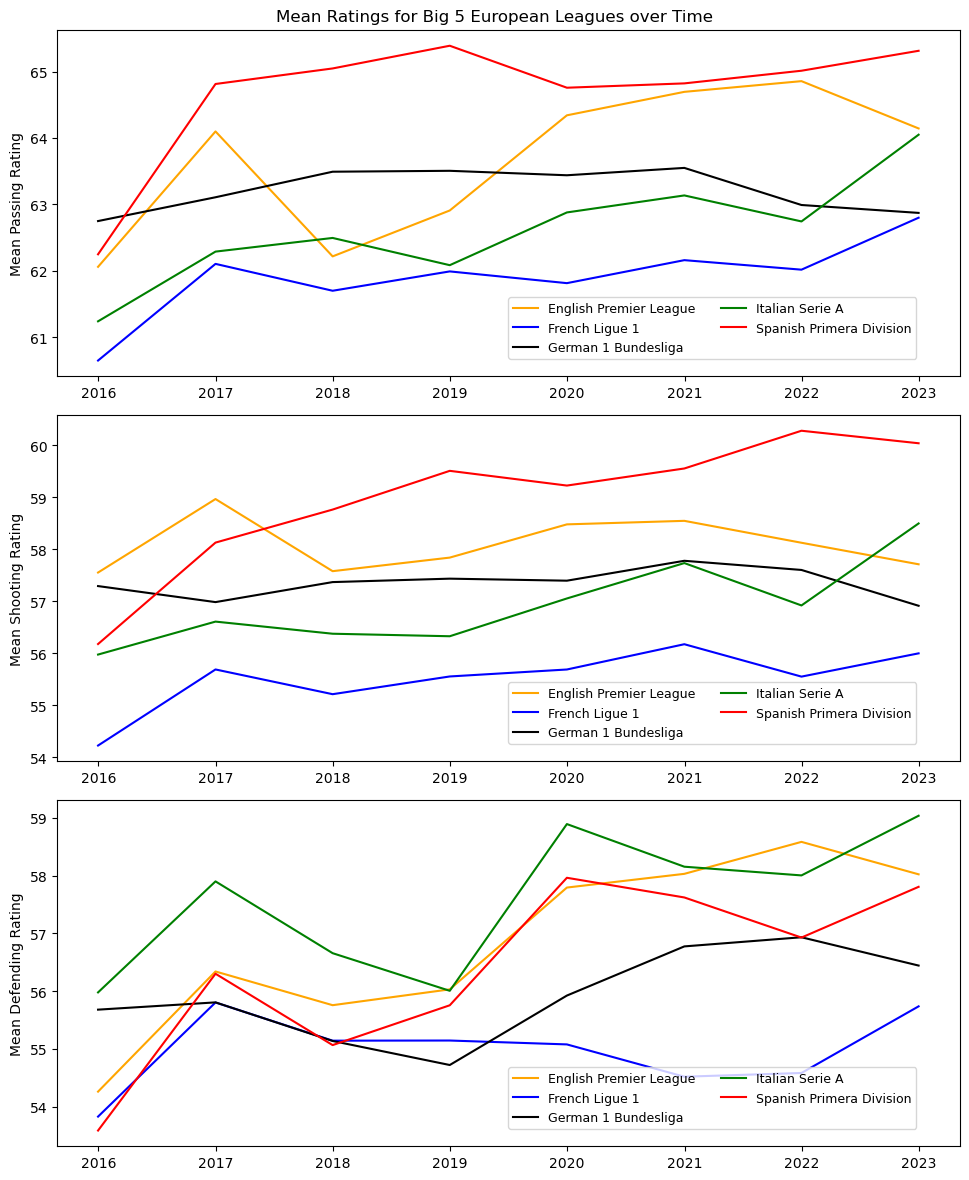

In [138]:


df_plot = league_agg.reset_index()

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Set plotting data sets for each league
df_epl = df_plot[df_plot["league_name"] == "English Premier League"]
df_fl1 = df_plot[df_plot["league_name"] == "French Ligue 1"]
df_g1b = df_plot[df_plot["league_name"] == "German 1. Bundesliga"]
df_isa = df_plot[df_plot["league_name"] == "Italian Serie A"]
df_spd = df_plot[df_plot["league_name"] == "Spain Primera Division"]

# Plot Mean Passing
axs[0].plot(df_epl["year"], df_epl["mean_passing"], c= "orange")
axs[0].plot(df_fl1["year"], df_fl1["mean_passing"], c="blue")
axs[0].plot(df_g1b["year"], df_g1b["mean_passing"], c="black")
axs[0].plot(df_isa["year"], df_isa["mean_passing"], c="green")
axs[0].plot(df_spd["year"], df_spd["mean_passing"], c="red")

# Plot Mean Shooting
axs[1].plot(df_epl["year"], df_epl["mean_shooting"], c= "orange")
axs[1].plot(df_fl1["year"], df_fl1["mean_shooting"], c="blue")
axs[1].plot(df_g1b["year"], df_g1b["mean_shooting"], c="black")
axs[1].plot(df_isa["year"], df_isa["mean_shooting"], c="green")
axs[1].plot(df_spd["year"], df_spd["mean_shooting"], c="red")

# Plot Mean Defending
axs[2].plot(df_epl["year"], df_epl["mean_defending"], c= "orange")
axs[2].plot(df_fl1["year"], df_fl1["mean_defending"], c="blue")
axs[2].plot(df_g1b["year"], df_g1b["mean_defending"], c="black")
axs[2].plot(df_isa["year"], df_isa["mean_defending"], c="green")
axs[2].plot(df_spd["year"], df_spd["mean_defending"], c="red")

# Set Legends
axs[0].legend(legend_lables, ncol = 2, fontsize = 9, loc = (.5,.05))
axs[1].legend(legend_lables, ncol = 2, fontsize = 9, loc = (.5,.05))
axs[2].legend(legend_lables, ncol = 2, fontsize = 9, loc = (.5,.05))

legend_lables = ["English Premier League", "French Ligue 1", "German 1 Bundesliga", "Italian Serie A",
                 "Spanish Primera Division"]

# Add Lables and Titles
axs[0].set_ylabel("Mean Passing Rating")
axs[1].set_ylabel("Mean Shooting Rating")
axs[2].set_ylabel("Mean Defending Rating")

fig.suptitle("Mean Ratings for Big 5 European Leagues over Time")

plt.tight_layout()
plt.show()

### For mean passing ratings over time our findings show that generally, the Spanish league has the highest mean ratings, followed by the English, German, Italian, and French. Ratings varied year by year, with the Spanish, Italian, and French leagues generally trending upwards, while the English one was more sporadic, and the German one generally constant. Mean passing ratings overall were higher than both mean shooting ratings and mean defending ratings.

### For mean shooting ratings, the ranking between leagues was very similar to mean passing ratingds. The Spanish league trended strongly upwards, with the Italian and French leagues slighly less so. The German and English leagues remained pretty steady. 

### For mean defending ratings, the Italian league is generally the highest, followed by the English and Spanish league, and then by the German and French Leagues. The leagues' mean defending rankings are all much closer than the other rankings, especially from 2016-2019. Most leagues trended upward here, epsecially the Spanish and English leagues.
